In [10]:
import torch
import torch.nn as nn
from datasets import load_dataset
from transformers import (
    ViTImageProcessor, 
    ViTForImageClassification, 
    TrainingArguments, 
    Trainer,
    DefaultDataCollator
)
from sklearn.metrics import fbeta_score
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from torchvision import transforms
from collections import defaultdict


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

processor_name = 'google/vit-base-patch16-224'
model_name = '../../saved_models/iteration_15'
id2label = {1: "1_hybrid", 0: "0_non-hybrid"}
label2id = {"1_hybrid": 1, "0_non-hybrid": 0}

processor = ViTImageProcessor.from_pretrained(processor_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# processor = ViTImageProcessor.from_pretrained(model_name)
# model = ViTForImageClassification.from_pretrained(model_name)

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

model.to(device)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 3952.71it/s]


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [26]:
def transform(example_batch):
    # Convert images to pixel values and add labels
    images = [augment(x) for x in example_batch['image']]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = example_batch['label']
    return inputs

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    f2_per_class = fbeta_score(
        labels,
        preds,
        beta=2,
        average=None
    )

    return {
        "f2_class_0": f2_per_class[0],
        "f2_class_1": f2_per_class[1],
    }

def prepare_loss_fn():
    labels = prepared_ds["train"].features["label"]

    class_names = labels.names
    num_classes = len(class_names)

    hybrid_idx = class_names.index("1_hybrid")

    class_weights = torch.ones(num_classes, device=device)
    class_weights[hybrid_idx] = 15

    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    return loss_fn

def create_results_folder():
    # create pretrained_vit_results directory if it doesn't exist
    if not os.path.exists("./pretrained_vit_results"):
        os.makedirs("./pretrained_vit_results")

    # get iteration number from existing pretrained_vit_results folders
    existing_folders = [f for f in os.listdir("./pretrained_vit_results") if f.startswith("iteration_")]
    iteration_numbers = [int(f.split("_")[1]) for f in existing_folders]

    # check if folder of max iteration is empty, if so, use that iteration number instead of creating a new one
    if iteration_numbers:
        max_iteration = max(iteration_numbers)
        if not os.listdir(f"./pretrained_vit_results/iteration_{max_iteration}"):
            next_iteration = max_iteration
        else:
            next_iteration = max_iteration + 1
    else:    
        next_iteration = 1
    
    new_folder_path = f"./pretrained_vit_results/iteration_{next_iteration}"
    return new_folder_path   

# Load the dataset
dataset = load_dataset("imagefolder", data_dir="../../butterfly_anomaly_image_resized")

prepared_ds = dataset.with_transform(transform)

loss_fn = prepare_loss_fn()

# Custom Trainer to use our loss function
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss



In [27]:
# for param in model.vit.parameters():
#     param.requires_grad = False

# for param in model.vit.encoder.layer[-2:].parameters():
#     param.requires_grad = True

# for param in model.vit.parameters():
#     param.requires_grad = True

training_args = TrainingArguments(
    output_dir=create_results_folder(),
    per_device_train_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=0.1,
    remove_unused_columns=False,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f2",
    greater_is_better=True,
    weight_decay=0.01,
    seed=42,
    report_to="none",
    disable_tqdm=True
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["validation"],
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
    callbacks=None
)


In [ ]:
# Train the model and save it
trainer.train()
trainer.save_model("./saved_models/model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.88s/it]


In [28]:
# Evaluate on test set
test_results = trainer.evaluate(prepared_ds["test"])
print(test_results)


{'eval_loss': '0.04504', 'eval_model_preparation_time': '0.0026', 'eval_f2_class_0': '0.9931', 'eval_f2_class_1': '0.9712', 'eval_runtime': '14.38', 'eval_samples_per_second': '46.25', 'eval_steps_per_second': '5.842', 'epoch': 0}
{'eval_loss': 0.045038532465696335, 'eval_model_preparation_time': 0.0026, 'eval_f2_class_0': 0.9931383170819791, 'eval_f2_class_1': 0.9712230215827338, 'eval_runtime': 14.3794, 'eval_samples_per_second': 46.247, 'eval_steps_per_second': 5.842, 'epoch': 0}


In [ ]:
# Show best F2 Score across all epochs for current training run
logs = trainer.state.log_history

f2_scores = []

for log in logs:
    if "eval_f2" in log:
        f2_scores.append(log["eval_f2"])

# Best F2 Score among all epochs
if f2_scores:
    best_f2 = max(f2_scores)
    print(f"Best F2 Score: {best_f2:.4f}")


NameError: name 'trainer' is not defined

In [ ]:
# Show all F2 Scores across all iterations
results = {}

base_path = "./pretrained_vit_results"

for folder in os.listdir(base_path):
    if folder.startswith("iteration_"):
        for checkpoint in os.listdir(os.path.join(base_path, folder)):
            path = os.path.join(base_path, folder, checkpoint, "trainer_state.json")
            if os.path.exists(path):
                with open(path) as f:
                    state = json.load(f)

                if folder not in results:
                    results[folder] = []

                results[folder].append(state.get("best_metric"))

# Print results
print(f"{'Iteration':<15} {'Best F2 Score':<15}")
for iteration, f2_list in sorted(results.items(), key=lambda x: int(x[0].split("_")[1])):
    # Get the best F2 score among all checkpoints in this iteration
    f2 = max(f2_list)  
    print(f"{iteration:<15} {f2}")
    

Iteration       Best F2 Score  
iteration_1     0.8545454545454545
iteration_2     0.8828828828828829
iteration_3     0.8896797153024911
iteration_4     0.8880994671403197
iteration_5     0.8938053097345132
iteration_6     0.8938053097345132
iteration_7     0.890652557319224
iteration_8     0.8938053097345132
iteration_9     0.8938053097345132
iteration_10    0.8938053097345132
iteration_11    0.7470414201183432
iteration_12    0.7704654895666132
iteration_13    0.7809847198641766
iteration_14    0.9171075837742504
iteration_15    0.9466911764705882


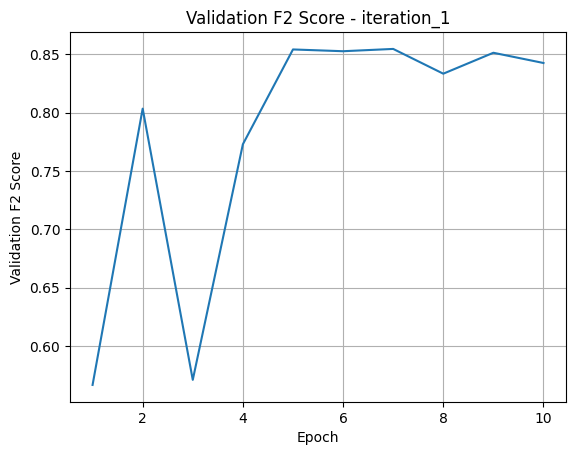

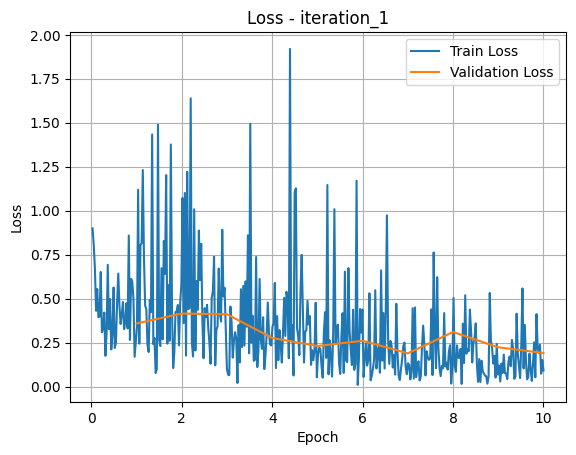

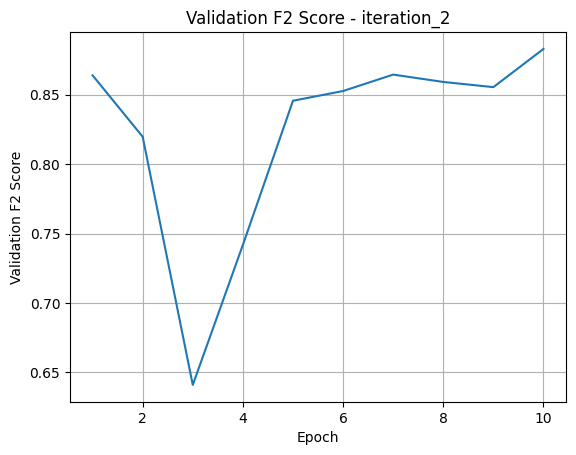

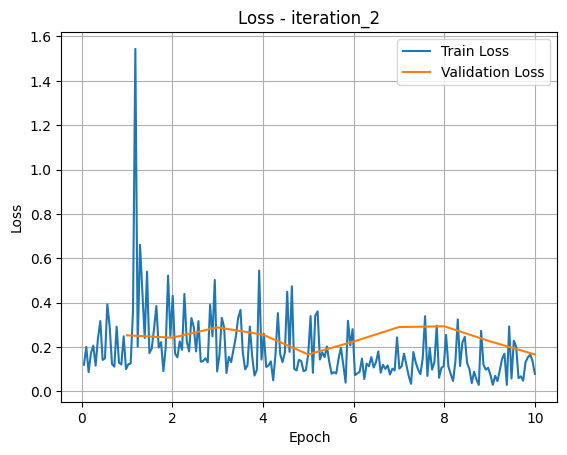

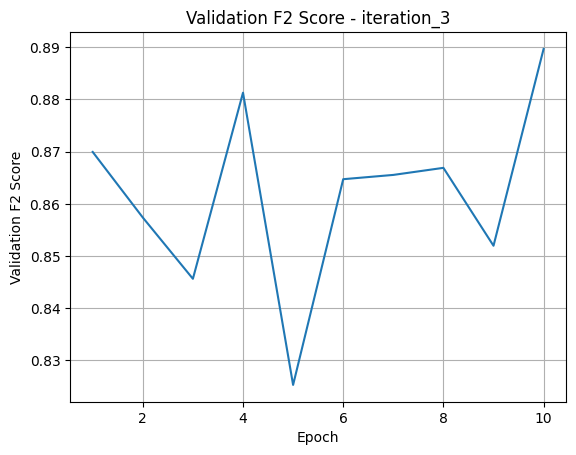

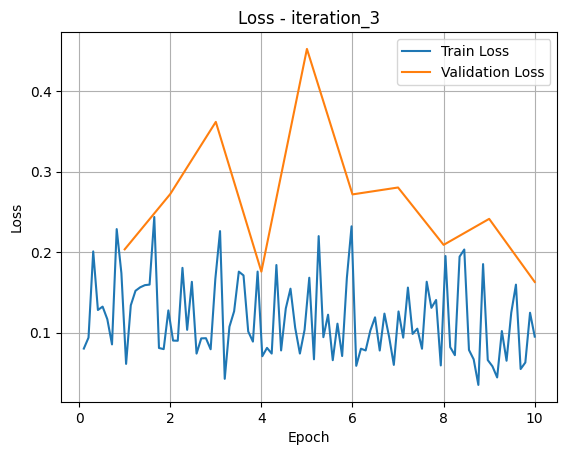

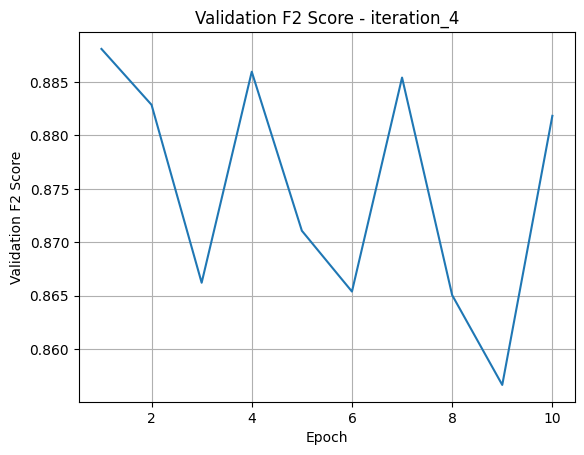

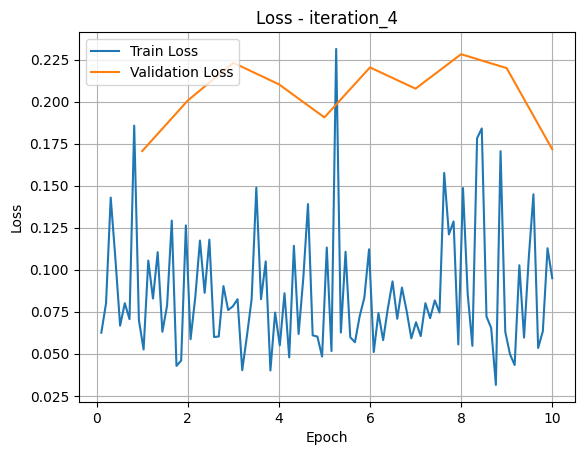

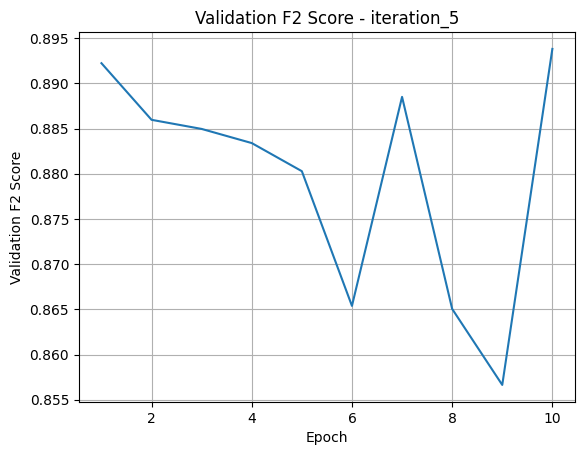

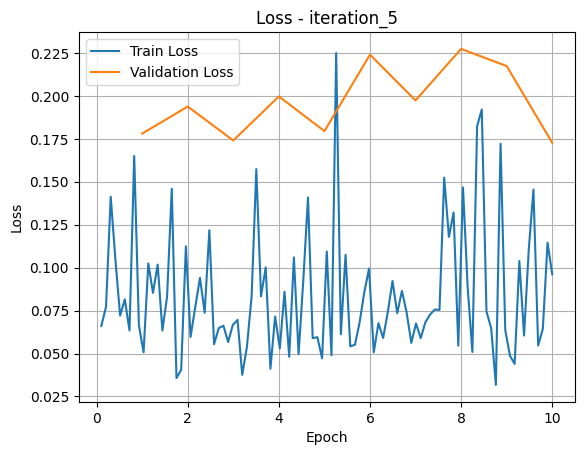

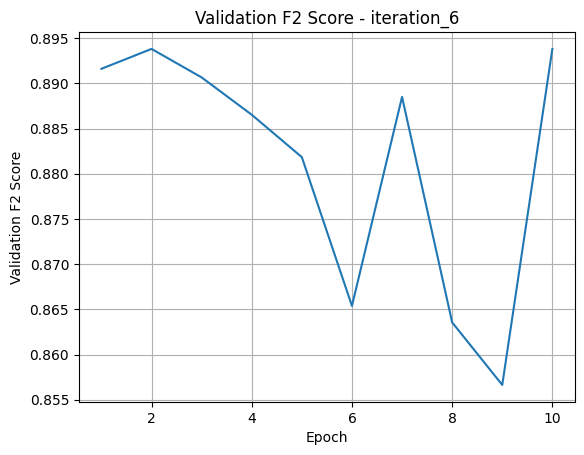

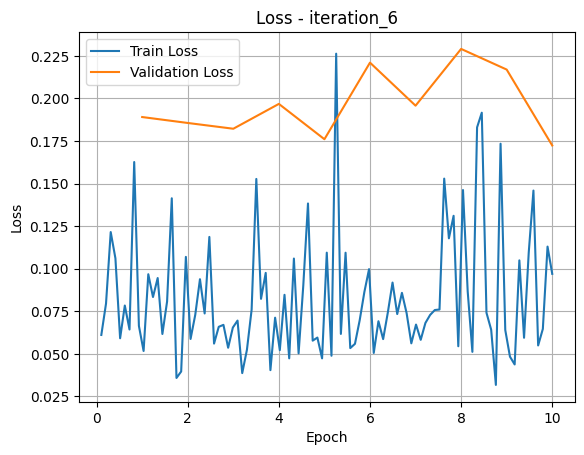

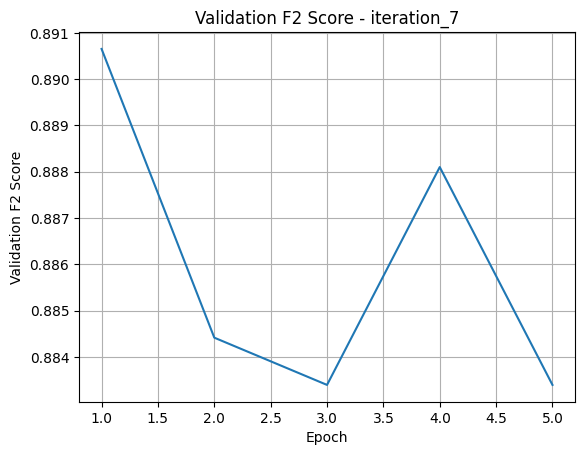

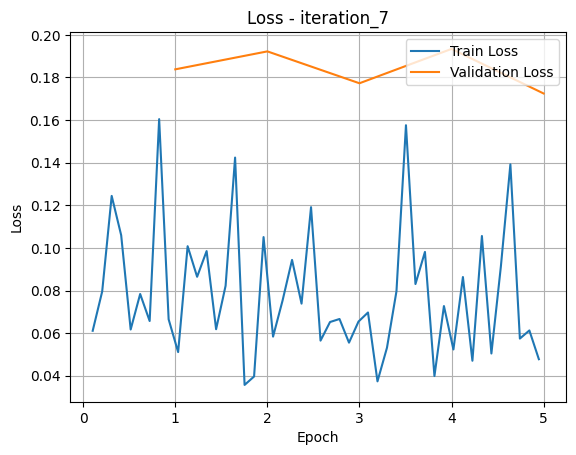

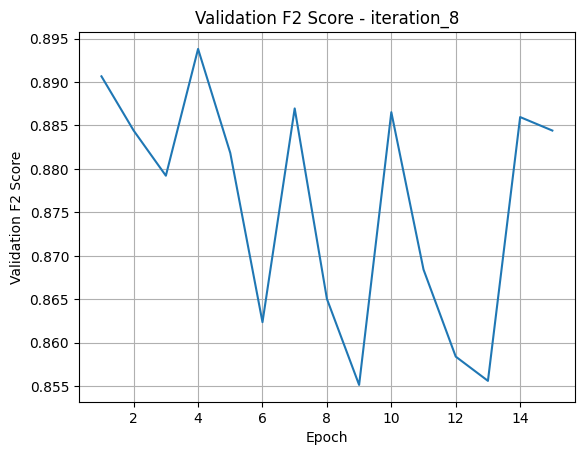

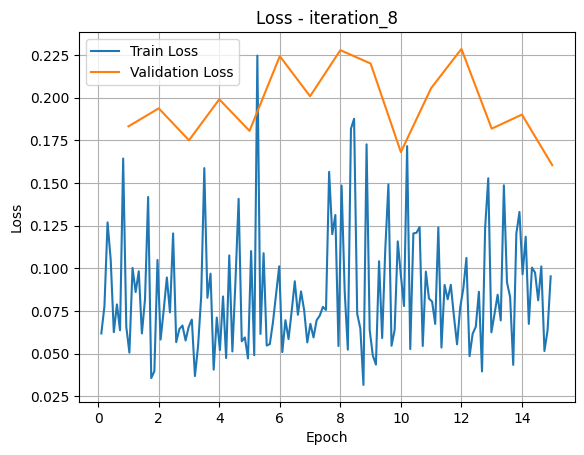

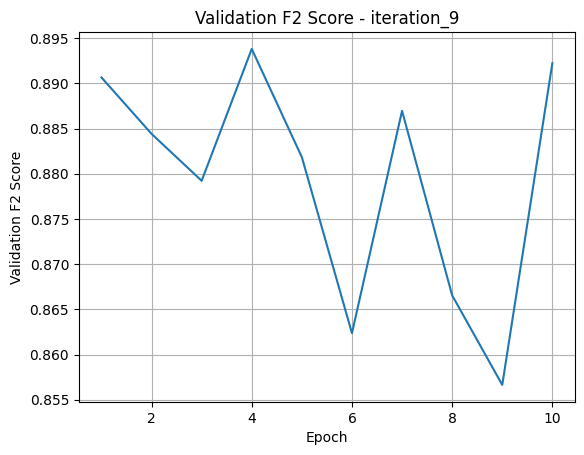

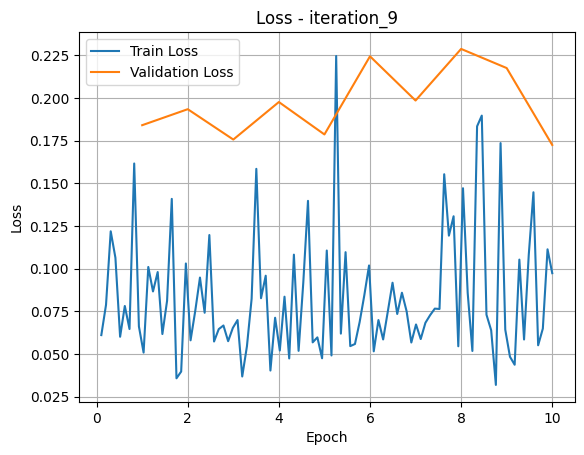

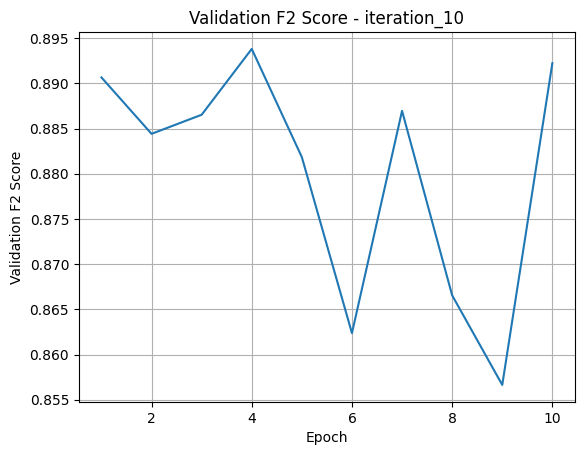

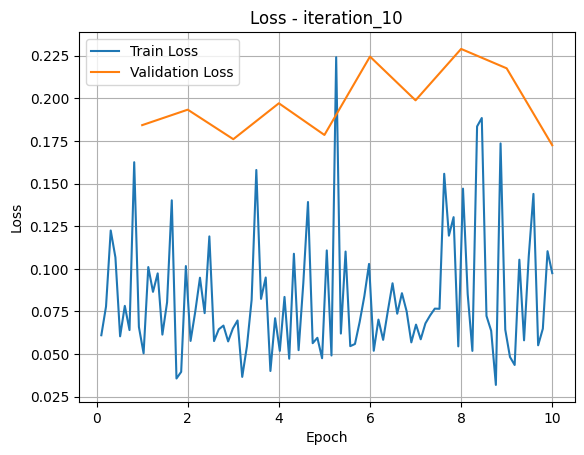

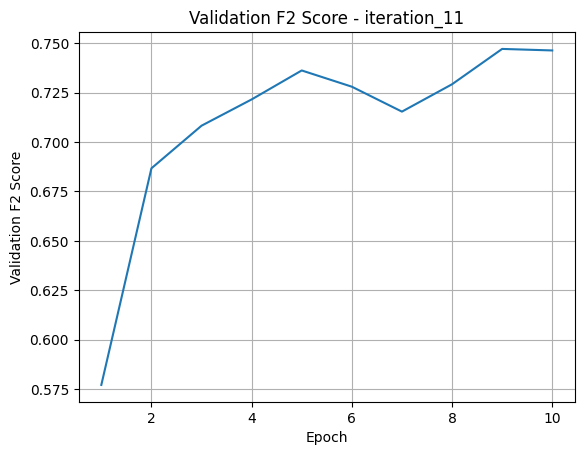

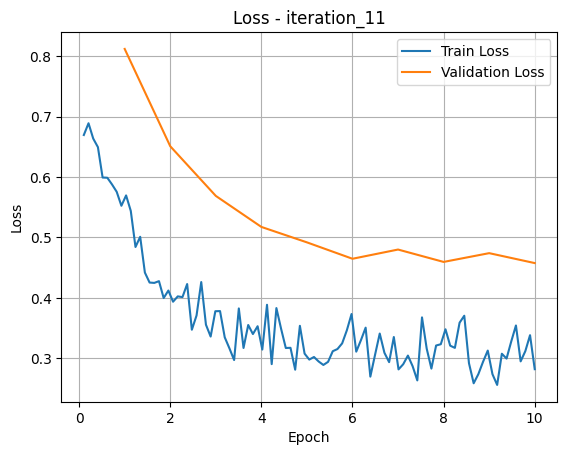

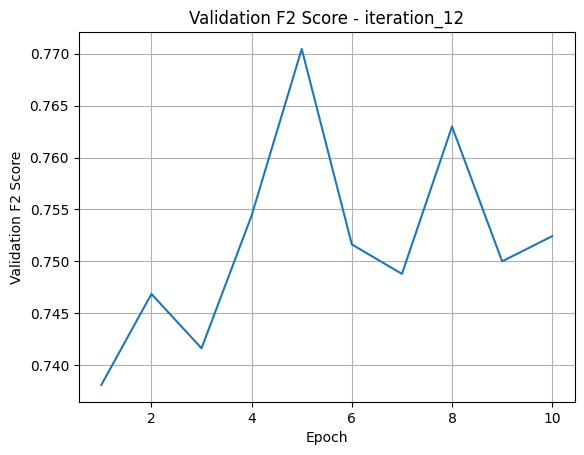

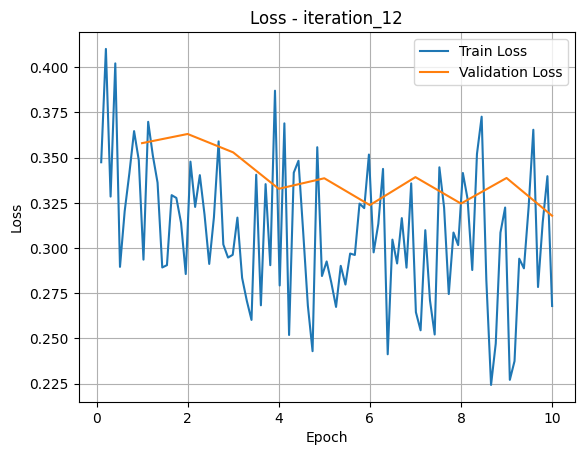

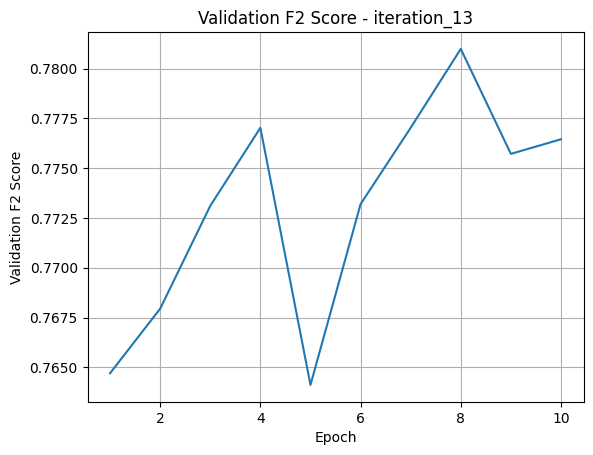

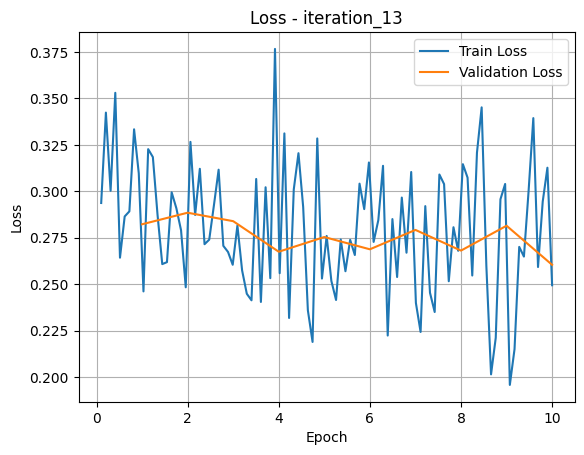

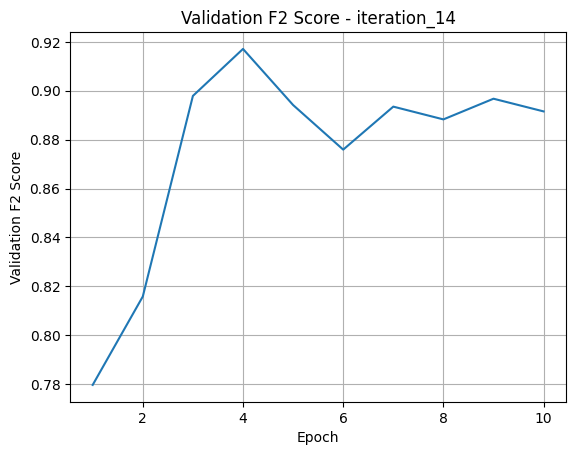

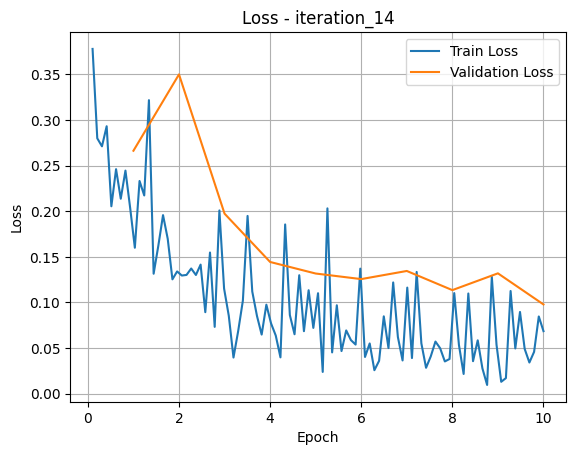

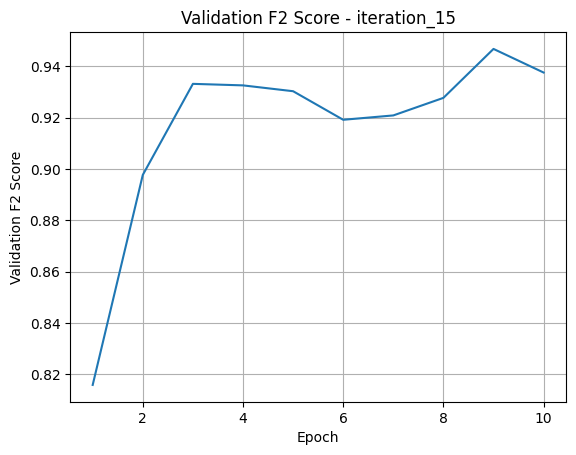

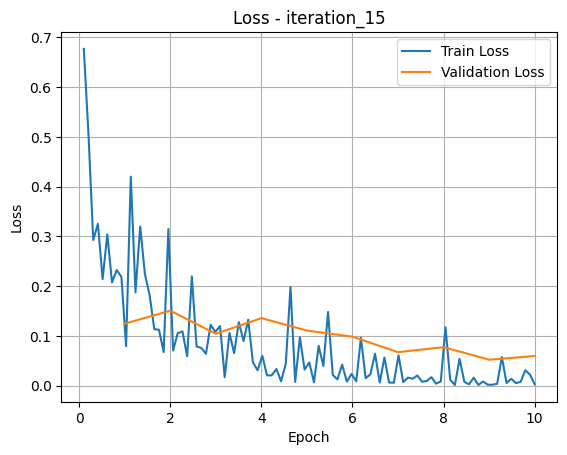

In [ ]:
metrics_data = {}

base_path = "./pretrained_vit_results"

for folder in os.listdir(base_path):
    if not folder.startswith("iteration_"):
        continue

    iteration_path = os.path.join(base_path, folder)

    # Get latest checkpoint
    checkpoints = [
        d for d in os.listdir(iteration_path)
        if d.startswith("checkpoint")
    ]

    if not checkpoints:
        continue

    checkpoints.sort(key=lambda x: int(x.split("-")[1]))
    latest_checkpoint = checkpoints[-1]

    path = os.path.join(iteration_path, latest_checkpoint, "trainer_state.json")

    if not os.path.exists(path):
        continue

    with open(path) as f:
        state = json.load(f)

    log_history = state.get("log_history", [])
    if len(log_history) == 0:
        continue

    # Get metrics per epoch
    train_loss = defaultdict(list)
    eval_loss = defaultdict(list)
    eval_f2 = defaultdict(list)

    for entry in log_history:
        epoch = entry.get("epoch")
        if epoch is None:
            continue

        if "loss" in entry:
            train_loss[epoch].append(entry["loss"])

        if "eval_loss" in entry:
            eval_loss[epoch].append(entry["eval_loss"])

        if "eval_f2" in entry:  # adjust if needed
            eval_f2[epoch].append(entry["eval_f2"])

    epochs = sorted(set(train_loss) | set(eval_loss) | set(eval_f2))

    # Store metrics for this iteration
    metrics_data[folder] = {
        "epoch": [],
        "train_loss": [],
        "eval_loss": [],
        "f2": []
    }

    for ep in epochs:
        metrics_data[folder]["epoch"].append(ep)

        metrics_data[folder]["train_loss"].append(
            train_loss[ep][-1] if ep in train_loss else None
        )

        metrics_data[folder]["eval_loss"].append(
            eval_loss[ep][-1] if ep in eval_loss else None
        )

        metrics_data[folder]["f2"].append(
            eval_f2[ep][-1] if ep in eval_f2 else None
        )


# Plotting graphs
for iteration, data in sorted(
    metrics_data.items(),
    key=lambda x: int(x[0].split("_")[1])
):
    epochs = data["epoch"]

    # Filter None values
    train_epochs = [e for e, v in zip(epochs, data["train_loss"]) if v is not None]
    train_vals = [v for v in data["train_loss"] if v is not None]

    eval_epochs = [e for e, v in zip(epochs, data["eval_loss"]) if v is not None]
    eval_vals = [v for v in data["eval_loss"] if v is not None]

    f2_epochs = [e for e, v in zip(epochs, data["f2"]) if v is not None]
    f2_vals = [v for v in data["f2"] if v is not None]

    # Validation F2 Score plot
    plt.figure()
    plt.plot(f2_epochs, f2_vals)
    plt.xlabel("Epoch")
    plt.ylabel("Validation F2 Score")
    plt.title(f"Validation F2 Score - {iteration}")
    plt.grid()
    plt.show()

    # Training and Validation Loss plot
    plt.figure()
    plt.plot(train_epochs, train_vals, label="Train Loss")
    plt.plot(eval_epochs, eval_vals, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {iteration}")
    plt.legend()
    plt.grid()
    plt.show()